In [12]:
from ase.build import bulk

from atomdefectkit.basic_properties import BasicProperties
from atomdefectkit.screw import BCCScrewDislocation
from atomdefectkit.neb import BCCScrewDislocPeierlsBarrier

import numpy as np

from pyace import PyACECalculator

In [13]:
# Define the benchmark material and output location.
elem = 'W'
crystal_structure = 'bcc'
initial_a0 = 3.3  # Initial lattice-parameter guess in Angstrom.
working_dir = 'Test_W'

calc = PyACECalculator('/Users/leizhang/Nextcloud/1_Science_Postdoc_Projects/0_0_RUG_Screw_BCC/9_1_data_git/ACE2025_potential/W/output_potential.yaml')


In [14]:
# Initialize the basic-property workflow with a direct ACE calculator.
workflow = BasicProperties(calculator=calc, working_dir=working_dir)

# Build the conventional cubic BCC unit cell.
atoms = bulk(elem, crystal_structure, a=initial_a0, cubic=True)

# Estimate the equilibrium lattice parameter from both relaxation and EOS fitting.
a0_relax = workflow.calculate_equilibrium_a0_relax(atoms.copy(), fmax=0.001)
volumes, energies, a0_fit = workflow.calculate_equilibrium_a0_birch_murnaghan(atoms.copy(), vol_range=np.linspace(0.95, 1.05, 40))

# Sanity-check that the two lattice-parameter estimates agree.
if abs(a0_relax - a0_fit) > 1e-4:
    print('Lattice constant difference is', abs(a0_relax - a0_fit))
    print('Check the approach for getting lattice constant!')

# Update the bulk cell before computing defect and surface properties.
atoms.set_cell([a0_fit] * 3, scale_atoms=True)

Lattice constant difference is 0.02227895635325794
Check the approach for getting lattice constant!


In [15]:
from atomdefectkit.stacking_fault import StackingFaultWorkflow


In [16]:
SF = StackingFaultWorkflow(
    atoms=atoms.copy(),
    calculator=calc,
    formula="Nb",
    info="ACE",
    optimizer="FIRE",
    working_dir=f'{working_dir}/stacking_fault',
)

[0.0, 0.07070977897524244, 0.2603996223771219, 0.5250712524870096, 0.8174264952186832, 1.0954050075806663, 1.3275956216280065, 1.5042131070994174, 1.6204514332600866, 1.6855420173432094, 1.7063632682584284, 1.6855411952459463, 1.6204504483622486, 1.5042136370425396, 1.3276002184032905, 1.0954157061133856, 0.8174426036891873, 0.5250895436695373, 0.2604157115497401, 0.07071926165872355, -6.760956239304505e-10]


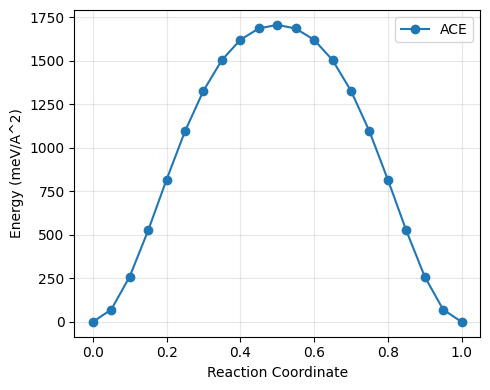

In [17]:
energies = SF.stacking_fault(
    a=(1, 1, -1),
    b=(1, 1, 2),
    miller=(1, -1, 0),
    distance=a0_fit/2,
    layers=30,
    num_steps=20,
    fmax=0.005,
    steps=1000,
    write_xyz=True,
)

print(energies)

[0.0, 0.011233593075246517, 0.029099072135181814, 0.05340060717276174, 0.08385668131137436, 0.12010810562208007, 0.16174533858605855, 0.20827466505784287, 0.25917610110280975, 0.31390513784174345, 0.3719050031253346, 0.43261813819913186, 0.49549594780978623, 0.5600069117809312, 0.6256431855338178, 0.6919257453189402, 0.7584080559331028, 0.8246782371044219, 0.8903794103777045, 0.9551779784620749, 1.0186908497547051, 1.0806890154620419, 1.1409252827087926, 1.1991799500308957, 1.2552588327429248, 1.309000275579308, 1.3602813501880746, 1.4090063114044824, 1.4550407473545306, 1.4984699060134403, 1.5392086698292928, 1.5772051809923369, 1.6126298887219264, 1.6454481846536737, 1.6757191090364927, 1.7033615385605572, 1.72871762267539, 1.7516992794670614, 1.7723402512655184, 1.7906579273277998, 1.8066546514260722, 1.8203217317058602, 1.8316464837269564, 1.8406231497840508, 1.847572368965757, 1.8518846942545224, 1.8539217410009883, 1.8537487005742719, 1.8514494267060968, 1.8471208099403498, 1.840

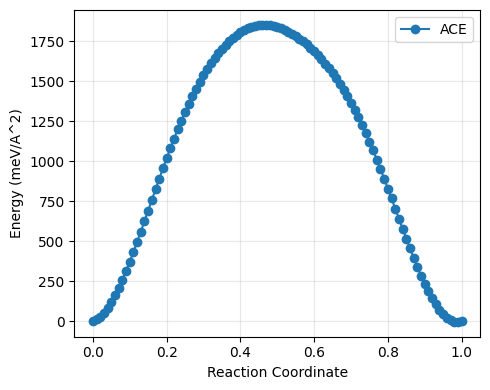

In [18]:
energies = SF.stacking_fault(
    a=(1, 1, -1),
    b=(-1, 1, 0),
    miller=(1, 1, 2),
    distance=a0_fit/2,
    layers=40,
    num_steps=100,
    fmax=0.005,
    steps=1000,
    write_xyz=True,
)

print(energies)